In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
file_path = '../data/raw/E Commerce Dataset.xlsx'

try:
    df = pd.read_excel(file_path, sheet_name='E Comm')
    print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
    
    display(df.head())
except FileNotFoundError:
    print(f"Error: Could not find the file at {file_path}. Please ensure it is in the correct folder.")

Dataset loaded successfully with 5630 rows and 20 columns.


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
# CustomerID  has no predictive power
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

missing_data = df.isnull().sum()
print("Missing Values per Feature:\n", missing_data[missing_data > 0])

# data types (categorical vs numerical)
print("\nData Types:\n", df.dtypes)

Missing Values per Feature:
 Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

Data Types:
 Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float

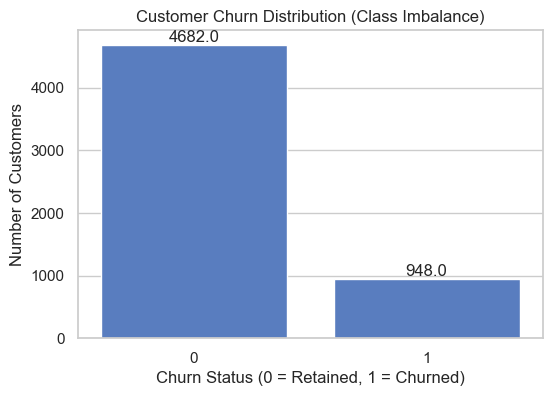

Churn Rate: 16.84% | Retention Rate: 83.16%


In [4]:
# 1 = Churned, 0 = Retained
churn_counts = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution (Class Imbalance)')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')

# Add percentage labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.show()
print(f"Churn Rate: {churn_counts[1]:.2f}% | Retention Rate: {churn_counts[0]:.2f}%")

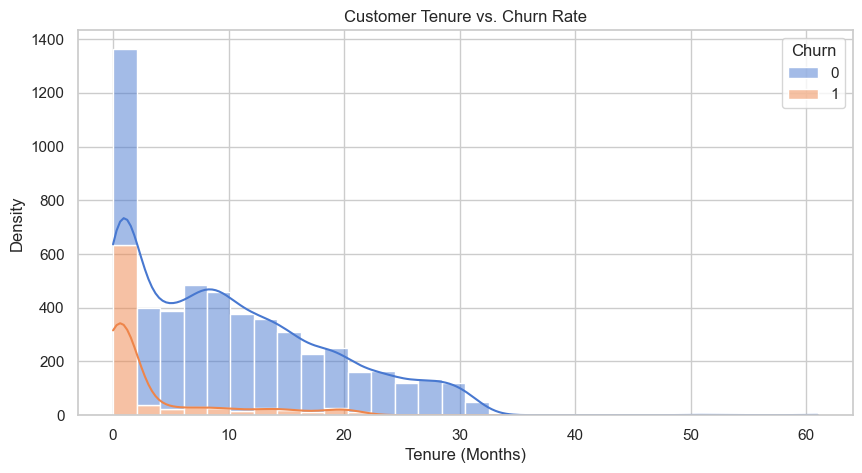

Insights: Early tenure (months 0-2) has the highest churn spikes.


In [5]:
# Visualizing continuous features against the target
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', bins=30, kde=True)
plt.title('Customer Tenure vs. Churn Rate')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.show()

print("Insights: Early tenure (months 0-2) has the highest churn spikes.")

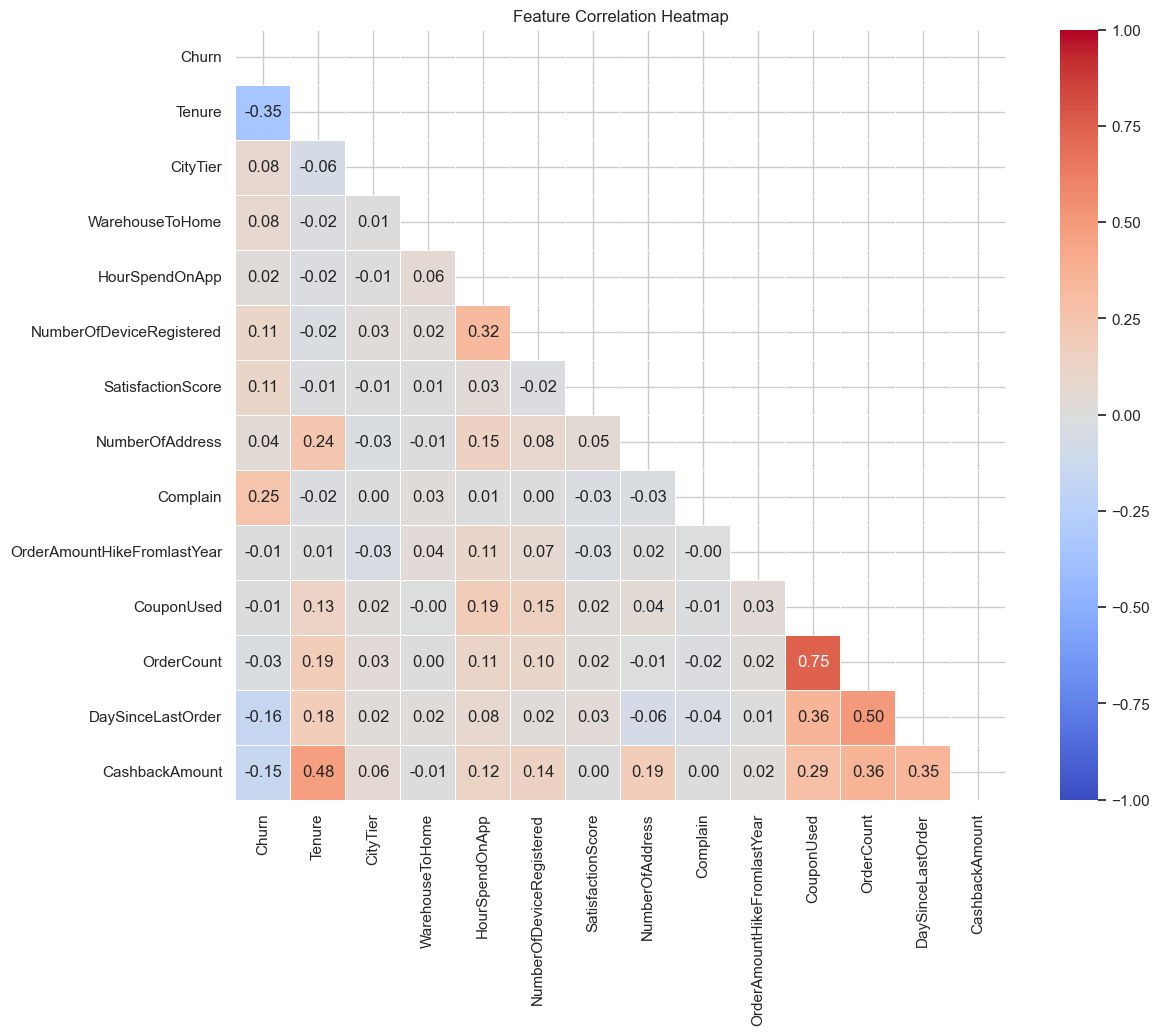

In [6]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# mask to hide the upper triangle for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)

plt.title('Feature Correlation Heatmap')
plt.show()